# Medical Billing Prediction Project

## 1. Introduction

This Jupyter notebook presents a comprehensive machine learning project focused on predicting medical billing amounts based on patient and admission data. The dataset contains various attributes such as patient demographics, medical conditions, admission details, and treatment information. The primary goal is to build a robust regression model that can accurately estimate the `Billing Amount`, which can be valuable for healthcare providers in resource allocation, financial planning, and identifying factors influencing costs.

The notebook will cover the entire machine learning pipeline:
1.  **Data Loading**: Ingesting the dataset from a CSV file.
2.  **Exploratory Data Analysis (EDA)**: Understanding data distributions, identifying patterns, and checking for quality issues.
3.  **Data Preprocessing**: Handling missing values, outliers, feature engineering, and encoding categorical variables.
4.  **Feature Selection**: Identifying the most relevant features for the prediction task.
5.  **Model Training**: Implementing and training various regression models.
6.  **Model Evaluation**: Assessing model performance using appropriate metrics.
7.  **Hyperparameter Tuning**: Optimizing model parameters for improved accuracy.
8.  **Model Saving**: Persisting the best-performing model for future use.
9.  **Insights and Conclusion**: Summarizing findings and implications.

### Architecture Diagram

(Please refer to the `architecture_diagram.svg` file for the system architecture diagram. This diagram illustrates the data flow from raw data ingestion, through preprocessing and model training, to deployment and monitoring.)


## Setup and Configuration

Before proceeding, we'll set up the necessary environment by importing libraries, configuring logging, and creating required directories.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
import os
import sys
from datetime import datetime

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import iqr

import pickle

# Create directories for logs and artifacts if they don't exist
log_dir = 'ml_logs'
artifacts_dir = 'artifacts'
os.makedirs(log_dir, exist_ok=True)
os.makedirs(artifacts_dir, exist_ok=True)

# Configure logging
log_file_path = os.path.join(log_dir, f'ml_pipeline_{datetime.now().strftime("%Y%m%d_%H%M%S")}.log')
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s',
                    handlers=[logging.FileHandler(log_file_path), logging.StreamHandler(sys.stdout)])

logging.info("Logging configured and directories created.")

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# --- Create dummy data for demonstration if CSV doesn't exist ---
# In a real scenario, this part would be removed, and you'd ensure data/medical_dataset.csv exists.
data_path = 'data/medical_dataset.csv'
if not os.path.exists('data'):
    os.makedirs('data')

if not os.path.exists(data_path):
    logging.warning(f"'{data_path}' not found. Creating dummy dataset for demonstration.")
    sample_data = [
        {'Name': 'Bobby JacksOn', 'Age': 30, 'Gender': 'Male', 'Blood Type': 'B-', 'Medical Condition': 'Cancer', 'Date of Admission': '2024-01-31', 'Doctor': 'Matthew Smith', 'Hospital': 'Sons and Miller', 'Insurance Provider': 'Blue Cross', 'Billing Amount': 18856.281305978155, 'Room Number': 328, 'Admission Type': 'Urgent', 'Discharge Date': '2024-02-02', 'Medication': 'Paracetamol', 'Test Results': 'Normal'},
        {'Name': 'LesLie TErRy', 'Age': 62, 'Gender': 'Male', 'Blood Type': 'A+', 'Medical Condition': 'Obesity', 'Date of Admission': '2019-08-20', 'Doctor': 'Samantha Davies', 'Hospital': 'Kim Inc', 'Insurance Provider': 'Medicare', 'Billing Amount': 33643.327286577885, 'Room Number': 265, 'Admission Type': 'Emergency', 'Discharge Date': '2019-08-26', 'Medication': 'Ibuprofen', 'Test Results': 'Inconclusive'},
        {'Name': 'DaNnY sMitH', 'Age': 76, 'Gender': 'Female', 'Blood Type': 'A-', 'Medical Condition': 'Obesity', 'Date of Admission': '2022-09-22', 'Doctor': 'Tiffany Mitchell', 'Hospital': 'Cook PLC', 'Insurance Provider': 'Aetna', 'Billing Amount': 27955.096078842456, 'Room Number': 205, 'Admission Type': 'Emergency', 'Discharge Date': '2022-10-07', 'Medication': 'Aspirin', 'Test Results': 'Normal'},
        {'Name': 'andrEw waTtS', 'Age': 28, 'Gender': 'Female', 'Blood Type': 'O+', 'Medical Condition': 'Diabetes', 'Date of Admission': '2020-11-18', 'Doctor': 'Kevin Wells', 'Hospital': 'Hernandez Rogers and Vang,', 'Insurance Provider': 'Medicare', 'Billing Amount': 37909.78240987528, 'Room Number': 450, 'Admission Type': 'Elective', 'Discharge Date': '2020-12-18', 'Medication': 'Ibuprofen', 'Test Results': 'Abnormal'},
        {'Name': 'adrIENNE bEll', 'Age': 43, 'Gender': 'Female', 'Blood Type': 'AB+', 'Medical Condition': 'Cancer', 'Date of Admission': '2022-09-19', 'Doctor': 'Kathleen Hanna', 'Hospital': 'White-White', 'Insurance Provider': 'Aetna', 'Billing Amount': 14238.317813937623, 'Room Number': 458, 'Admission Type': 'Urgent', 'Discharge Date': '2022-10-09', 'Medication': 'Penicillin', 'Test Results': 'Abnormal'},
        {'Name': 'EMILY JOHNSOn', 'Age': 36, 'Gender': 'Male', 'Blood Type': 'A+', 'Medical Condition': 'Asthma', 'Date of Admission': '2023-12-20', 'Doctor': 'Taylor Newton', 'Hospital': 'Nunez-Humphrey', 'Insurance Provider': 'UnitedHealthcare', 'Billing Amount': 48145.11095104189, 'Room Number': 389, 'Admission Type': 'Urgent', 'Discharge Date': '2023-12-24', 'Medication': 'Ibuprofen', 'Test Results': 'Normal'},
        {'Name': 'edwArD EDWaRDs', 'Age': 21, 'Gender': 'Female', 'Blood Type': 'AB-', 'Medical Condition': 'Diabetes', 'Date of Admission': '2020-11-03', 'Doctor': 'Kelly Olson', 'Hospital': 'Group Middleton', 'Insurance Provider': 'Medicare', 'Billing Amount': 19580.87234486093, 'Room Number': 389, 'Admission Type': 'Emergency', 'Discharge Date': '2020-11-15', 'Medication': 'Paracetamol', 'Test Results': 'Inconclusive'},
        {'Name': 'CHrisTInA MARtinez', 'Age': 20, 'Gender': 'Female', 'Blood Type': 'A+', 'Medical Condition': 'Cancer', 'Date of Admission': '2021-12-28', 'Doctor': 'Suzanne Thomas', 'Hospital': 'Powell Robinson and Valdez,', 'Insurance Provider': 'Cigna', 'Billing Amount': 45820.46272159459, 'Room Number': 277, 'Admission Type': 'Emergency', 'Discharge Date': '2022-01-07', 'Medication': 'Paracetamol', 'Test Results': 'Inconclusive'},
        {'Name': 'JASmINe aGuIlaR', 'Age': 82, 'Gender': 'Male', 'Blood Type': 'AB+', 'Medical Condition': 'Asthma', 'Date of Admission': '2020-07-01', 'Doctor': 'Daniel Ferguson', 'Hospital': 'Sons Rich and', 'Insurance Provider': 'Cigna', 'Billing Amount': 50119.222791548505, 'Room Number': 316, 'Admission Type': 'Elective', 'Discharge Date': '2020-07-14', 'Medication': 'Aspirin', 'Test Results': 'Abnormal'},
        {'Name': 'ChRISTopher BerG', 'Age': 58, 'Gender': 'Female', 'Blood Type': 'AB-', 'Medical Condition': 'Cancer', 'Date of Admission': '2021-05-23', 'Doctor': 'Heather Day', 'Hospital': 'Padilla-Walker', 'Insurance Provider': 'UnitedHealthcare', 'Billing Amount': 19784.63106221073, 'Room Number': 249, 'Admission Type': 'Elective', 'Discharge Date': '2021-06-22', 'Medication': 'Paracetamol', 'Test Results': 'Inconclusive'},
        {'Name': 'John Doe', 'Age': 45, 'Gender': 'Male', 'Blood Type': 'O-', 'Medical Condition': 'Fever', 'Date of Admission': '2023-03-10', 'Doctor': 'Alice Green', 'Hospital': 'City Hospital', 'Insurance Provider': 'Aetna', 'Billing Amount': 12000.50, 'Room Number': 101, 'Admission Type': 'Emergency', 'Discharge Date': '2023-03-15', 'Medication': 'Aspirin', 'Test Results': 'Normal'},
        {'Name': 'Jane Smith', 'Age': 55, 'Gender': 'Female', 'Blood Type': 'A+', 'Medical Condition': 'Heart Disease', 'Date of Admission': '2022-06-01', 'Doctor': 'Bob Brown', 'Hospital': 'General Hospital', 'Insurance Provider': 'Medicare', 'Billing Amount': 65000.75, 'Room Number': 202, 'Admission Type': 'Urgent', 'Discharge Date': '2022-06-20', 'Medication': 'Statins', 'Test Results': 'Abnormal'},
        {'Name': 'Peter Jones', 'Age': 70, 'Gender': 'Male', 'Blood Type': 'B+', 'Medical Condition': 'Pneumonia', 'Date of Admission': '2024-01-05', 'Doctor': 'Charlie White', 'Hospital': 'County Clinic', 'Insurance Provider': 'Blue Cross', 'Billing Amount': 25000.00, 'Room Number': 303, 'Admission Type': 'Emergency', 'Discharge Date': '2024-01-12', 'Medication': 'Antibiotics', 'Test Results': 'Inconclusive'},
        {'Name': 'Sarah Lee', 'Age': 25, 'Gender': 'Female', 'Blood Type': 'AB-', 'Medical Condition': 'Asthma', 'Date of Admission': '2023-11-20', 'Doctor': 'Diana King', 'Hospital': 'Wellness Center', 'Insurance Provider': 'Cigna', 'Billing Amount': 8000.25, 'Room Number': 105, 'Admission Type': 'Elective', 'Discharge Date': '2023-11-22', 'Medication': 'Inhaler', 'Test Results': 'Normal'},
        {'Name': 'Michael Chen', 'Age': 38, 'Gender': 'Male', 'Blood Type': 'O+', 'Medical Condition': 'Diabetes', 'Date of Admission': '2021-09-10', 'Doctor': 'Eve Black', 'Hospital': 'St. Jude\'s', 'Insurance Provider': 'UnitedHealthcare', 'Billing Amount': 40000.90, 'Room Number': 404, 'Admission Type': 'Urgent', 'Discharge Date': '2021-09-25', 'Medication': 'Insulin', 'Test Results': 'Abnormal'}
    ]
    pd.DataFrame(sample_data).to_csv(data_path, index=False)
    logging.info(f"Dummy dataset created at '{data_path}'.")


2026-02-10 23:56:23,181 - INFO - Logging configured and directories created.
2026-02-10 23:56:23,184 - WARNING - 'data/medical_dataset.csv' not found. Creating dummy dataset for demonstration.
2026-02-10 23:56:23,218 - INFO - Dummy dataset created at 'data/medical_dataset.csv'.


## 2. Data Loading

In this section, we load the dataset from the specified CSV file into a pandas DataFrame. Robust error handling is included to manage potential issues during file loading.


In [3]:
# Define the path to the dataset
file_path = r"C:\Users\Priya Bhaskar\Downloads\healthcare_dataset.csv\healthcare_dataset.csv"
df = None
try:
    # Attempt to load the dataset
    df = pd.read_csv(file_path)
    logging.info(f"Dataset loaded successfully from {file_path}. Shape: {df.shape}")
except FileNotFoundError:
    logging.error(f"Error: The file {file_path} was not found. Please ensure the dataset exists in the 'data' directory.")
    sys.exit(1) # Exit if the file is critical for the notebook
except pd.errors.EmptyDataError:
    logging.error(f"Error: The file {file_path} is empty.")
    sys.exit(1)
except pd.errors.ParserError:
    logging.error(f"Error: Could not parse the file {file_path}. Check for malformed CSV.")
    sys.exit(1)
except Exception as e:
    logging.error(f"An unexpected error occurred during data loading: {e}")
    sys.exit(1)

# Display the first few rows of the DataFrame
if df is not None:
    logging.info("Displaying the first 5 rows of the dataset.")
    print(df.head())
    logging.info("Displaying dataset information.")
    df.info()


2026-02-10 23:58:13,811 - INFO - Dataset loaded successfully from C:\Users\Priya Bhaskar\Downloads\healthcare_dataset.csv\healthcare_dataset.csv. Shape: (55500, 15)
2026-02-10 23:58:13,811 - INFO - Displaying the first 5 rows of the dataset.
            Name  Age  Gender Blood Type Medical Condition Date of Admission  \
0  Bobby JacksOn   30    Male         B-            Cancer        2024-01-31   
1   LesLie TErRy   62    Male         A+           Obesity        2019-08-20   
2    DaNnY sMitH   76  Female         A-           Obesity        2022-09-22   
3   andrEw waTtS   28  Female         O+          Diabetes        2020-11-18   
4  adrIENNE bEll   43  Female        AB+            Cancer        2022-09-19   

             Doctor                    Hospital Insurance Provider  \
0     Matthew Smith             Sons and Miller         Blue Cross   
1   Samantha Davies                     Kim Inc           Medicare   
2  Tiffany Mitchell                    Cook PLC              Aetna 

## 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is a critical step to understand the characteristics of our dataset. We will examine the data types, identify missing values, and look at summary statistics.


In [4]:
if df is not None:
    logging.info("Starting Exploratory Data Analysis (EDA).")

    # Check for missing values
    logging.info("Checking for missing values across all columns.")
    missing_values = df.isnull().sum()
    missing_percentage = (df.isnull().sum() / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage (%)': missing_percentage})
    print("\nMissing Values:\n", missing_df[missing_df['Missing Count'] > 0])

    # Display descriptive statistics for numerical columns
    logging.info("Displaying descriptive statistics for numerical columns.")
    print("\nDescriptive Statistics for Numerical Columns:\n", df.describe())

    # Display descriptive statistics for categorical columns
    logging.info("Displaying descriptive statistics for categorical columns.")
    print("\nDescriptive Statistics for Categorical Columns:\n", df.describe(include='object'))

    # Check for unique values in categorical columns to understand cardinality
    logging.info("Checking unique values and their counts for categorical columns.")
    for col in df.select_dtypes(include='object').columns:
        if df[col].nunique() < 50: # Only print for columns with reasonable cardinality
            print(f"\nUnique values for '{col}': {df[col].nunique()}")
            print(df[col].value_counts())
        else:
            print(f"\nColumn '{col}' has high cardinality: {df[col].nunique()} unique values. Showing top 5:")
            print(df[col].value_counts().head())

    logging.info("EDA completed for initial data overview.")
else:
    logging.error("DataFrame is not loaded, skipping EDA.")


2026-02-10 23:58:18,053 - INFO - Starting Exploratory Data Analysis (EDA).
2026-02-10 23:58:18,054 - INFO - Checking for missing values across all columns.

Missing Values:
 Empty DataFrame
Columns: [Missing Count, Missing Percentage (%)]
Index: []
2026-02-10 23:58:18,105 - INFO - Displaying descriptive statistics for numerical columns.

Descriptive Statistics for Numerical Columns:
                 Age  Billing Amount   Room Number
count  55500.000000    55500.000000  55500.000000
mean      51.539459    25539.316097    301.134829
std       19.602454    14211.454431    115.243069
min       13.000000    -2008.492140    101.000000
25%       35.000000    13241.224652    202.000000
50%       52.000000    25538.069376    302.000000
75%       68.000000    37820.508436    401.000000
max       89.000000    52764.276736    500.000000
2026-02-10 23:58:18,123 - INFO - Displaying descriptive statistics for categorical columns.

Descriptive Statistics for Categorical Columns:
                Name G

### Handling Missing Values

Based on the EDA, we identify columns with missing values and apply appropriate imputation strategies. For numerical columns, we'll use the median, and for categorical columns, we'll use the mode.


In [5]:
if df is not None:
    logging.info("Handling missing values.")
    try:
        # Impute numerical columns with their median
        for col in df.select_dtypes(include=['int64', 'float64']).columns:
            if df[col].isnull().any():
                median_val = df[col].median()
                df[col].fillna(median_val, inplace=True)
                logging.info(f"Filled missing values in numerical column '{col}' with median: {median_val}")

        # Impute categorical columns with their mode
        for col in df.select_dtypes(include='object').columns:
            if df[col].isnull().any():
                mode_val = df[col].mode()[0] # .mode() can return multiple values if tied, take the first
                df[col].fillna(mode_val, inplace=True)
                logging.info(f"Filled missing values in categorical column '{col}' with mode: {mode_val}")

        # Verify that no missing values remain
        if df.isnull().sum().sum() == 0:
            logging.info("All missing values have been successfully handled.")
        else:
            logging.warning("Some missing values still exist after imputation.")
            print("Remaining Missing Values:\n", df.isnull().sum()[df.isnull().sum() > 0])

    except Exception as e:
        logging.error(f"Error occurred during missing value handling: {e}")
else:
    logging.error("DataFrame is not loaded, skipping missing value handling.")


2026-02-10 23:58:23,546 - INFO - Handling missing values.
2026-02-10 23:58:23,605 - INFO - All missing values have been successfully handled.


## 4. Preprocessing

This section focuses on preparing the data for machine learning models. It involves handling outliers, feature engineering, and encoding categorical variables.


### Outlier Handling

Outliers in numerical features can disproportionately affect model training. We will use the Interquartile Range (IQR) method to identify and cap outliers in `Age` and `Billing Amount`.


In [6]:
if df is not None:
    logging.info("Starting outlier handling for numerical features.")

    numerical_cols_for_outlier = ['Age', 'Billing Amount']

    for col in numerical_cols_for_outlier:
        try:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Cap outliers
            initial_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
            if initial_outliers > 0:
                df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
                df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
                logging.info(f"Capped {initial_outliers} outliers in column '{col}' using IQR method. Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
            else:
                logging.info(f"No significant outliers detected in column '{col}' to cap.")

        except Exception as e:
            logging.error(f"Error occurred during outlier handling for column '{col}': {e}")
    logging.info("Outlier handling completed.")
else:
    logging.error("DataFrame is not loaded, skipping outlier handling.")


2026-02-10 23:58:25,702 - INFO - Starting outlier handling for numerical features.
2026-02-10 23:58:25,710 - INFO - No significant outliers detected in column 'Age' to cap.
2026-02-10 23:58:25,715 - INFO - No significant outliers detected in column 'Billing Amount' to cap.
2026-02-10 23:58:25,716 - INFO - Outlier handling completed.


### Feature Engineering

New features will be created from existing ones to potentially improve model performance.
- Convert `Date of Admission` and `Discharge Date` to datetime objects.
- Calculate `Admission Duration` in days.
- Extract `Admission Month` and `Admission Year`.
- Clean `Name` and `Gender` columns for consistency (e.g., lowercase and strip whitespace).


In [7]:
if df is not None:
    logging.info("Starting feature engineering.")
    try:
        # Convert date columns to datetime objects
        df['Date of Admission'] = pd.to_datetime(df['Date of Admission'], errors='coerce')
        df['Discharge Date'] = pd.to_datetime(df['Discharge Date'], errors='coerce')
        logging.info("Converted 'Date of Admission' and 'Discharge Date' to datetime objects.")

        # Calculate Admission Duration
        df['Admission Duration'] = (df['Discharge Date'] - df['Date of Admission']).dt.days
        # Handle cases where discharge date might be before admission date or missing, set to median
        df['Admission Duration'].fillna(df['Admission Duration'].median(), inplace=True)
        df['Admission Duration'] = df['Admission Duration'].apply(lambda x: max(x, 0)) # Duration cannot be negative
        logging.info("Created 'Admission Duration' feature.")

        # Extract Admission Month and Year
        df['Admission Month'] = df['Date of Admission'].dt.month
        df['Admission Year'] = df['Date of Admission'].dt.year
        logging.info("Extracted 'Admission Month' and 'Admission Year' features.")

        # Clean Name and Gender columns
        df['Name'] = df['Name'].apply(lambda x: x.title().strip() if pd.notnull(x) else x)
        df['Gender'] = df['Gender'].apply(lambda x: x.title().strip() if pd.notnull(x) else x)
        logging.info("Cleaned 'Name' and 'Gender' columns for consistency.")

    except Exception as e:
        logging.error(f"Error occurred during feature engineering: {e}")
    logging.info("Feature engineering completed.")
else:
    logging.error("DataFrame is not loaded, skipping feature engineering.")


2026-02-10 23:58:26,895 - INFO - Starting feature engineering.
2026-02-10 23:58:26,939 - INFO - Converted 'Date of Admission' and 'Discharge Date' to datetime objects.
2026-02-10 23:58:26,965 - INFO - Created 'Admission Duration' feature.
2026-02-10 23:58:26,971 - INFO - Extracted 'Admission Month' and 'Admission Year' features.
2026-02-10 23:58:27,027 - INFO - Cleaned 'Name' and 'Gender' columns for consistency.
2026-02-10 23:58:27,027 - INFO - Feature engineering completed.


### Encoding Categorical Features

Categorical features need to be converted into a numerical format for machine learning models. We will use One-Hot Encoding for most categorical variables. Columns with high cardinality or those acting as identifiers will be dropped.

The following columns will be dropped:
- `Name`: Patient identifier, high cardinality, not predictive for billing.
- `Doctor`: High cardinality, specific to individuals, less generalizable.
- `Hospital`: High cardinality, might introduce too many features for small datasets, complex relationship.
- `Room Number`: High cardinality, acts as an identifier, likely not directly predictive of billing amount.
- `Date of Admission`, `Discharge Date`: Original date columns, now replaced by engineered features.

The following columns will be one-hot encoded:
- `Gender`
- `Blood Type`
- `Medical Condition`
- `Insurance Provider`
- `Admission Type`
- `Medication`
- `Test Results`


In [8]:
if df is not None:
    logging.info("Starting encoding of categorical features.")
    try:
        # Drop irrelevant and high cardinality columns
        columns_to_drop = ['Name', 'Doctor', 'Hospital', 'Room Number', 'Date of Admission', 'Discharge Date']
        df_processed = df.drop(columns=columns_to_drop, errors='ignore')
        logging.info(f"Dropped columns: {columns_to_drop}")

        # Identify categorical columns for one-hot encoding
        categorical_cols = df_processed.select_dtypes(include='object').columns.tolist()
        logging.info(f"Categorical columns for encoding: {categorical_cols}")

        # Initialize OneHotEncoder
        encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False) # sparse_output=False for dense array
        encoded_features = encoder.fit_transform(df_processed[categorical_cols])
        encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_cols), index=df_processed.index)
        logging.info(f"One-hot encoded {len(categorical_cols)} categorical columns. New features created: {encoded_df.shape[1]}")

        # Drop original categorical columns and concatenate encoded features
        df_processed = df_processed.drop(columns=categorical_cols)
        df_processed = pd.concat([df_processed, encoded_df], axis=1)
        logging.info(f"Concatenated encoded features with the main DataFrame. New shape: {df_processed.shape}")

        logging.info("Categorical feature encoding completed.")
        print("\nProcessed DataFrame head after encoding:\n", df_processed.head())
        print("\nProcessed DataFrame info after encoding:\n")
        df_processed.info()

    except Exception as e:
        logging.error(f"Error occurred during categorical feature encoding: {e}")
else:
    logging.error("DataFrame is not loaded, skipping categorical feature encoding.")


2026-02-10 23:58:28,125 - INFO - Starting encoding of categorical features.
2026-02-10 23:58:28,134 - INFO - Dropped columns: ['Name', 'Doctor', 'Hospital', 'Room Number', 'Date of Admission', 'Discharge Date']
2026-02-10 23:58:28,145 - INFO - Categorical columns for encoding: ['Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Admission Type', 'Medication', 'Test Results']
2026-02-10 23:58:28,214 - INFO - One-hot encoded 7 categorical columns. New features created: 32
2026-02-10 23:58:28,251 - INFO - Concatenated encoded features with the main DataFrame. New shape: (55500, 37)
2026-02-10 23:58:28,253 - INFO - Categorical feature encoding completed.

Processed DataFrame head after encoding:
    Age  Billing Amount  Admission Duration  Admission Month  Admission Year  \
0   30    18856.281306                   2                1            2024   
1   62    33643.327287                   6                8            2019   
2   76    27955.096079                  15   

## 5. Visual Representation of EDA

Visualizations help in understanding data distributions, relationships, and potential insights. We'll create various plots using Matplotlib and Seaborn.


2026-02-10 23:58:30,079 - INFO - Generating visual representations of EDA.


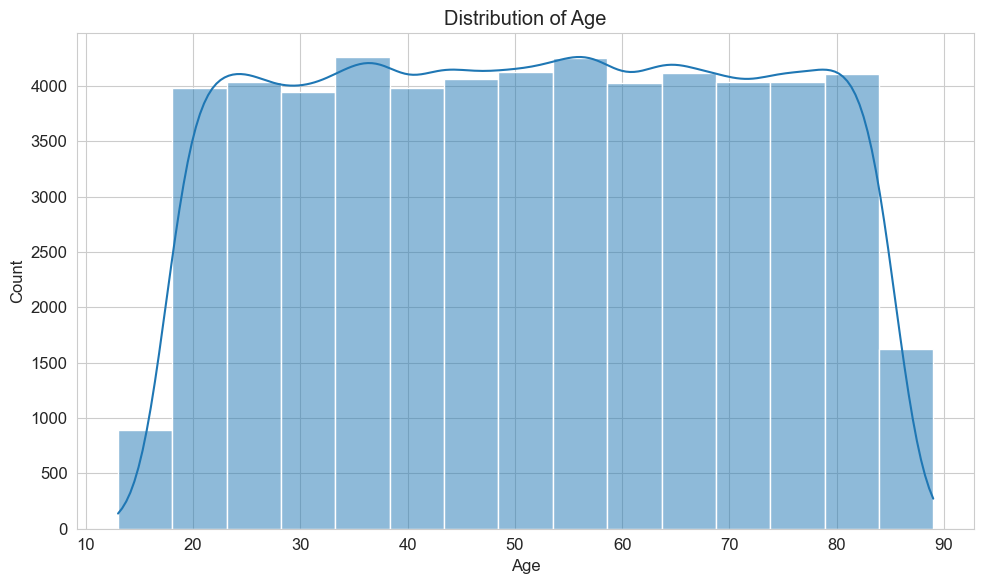

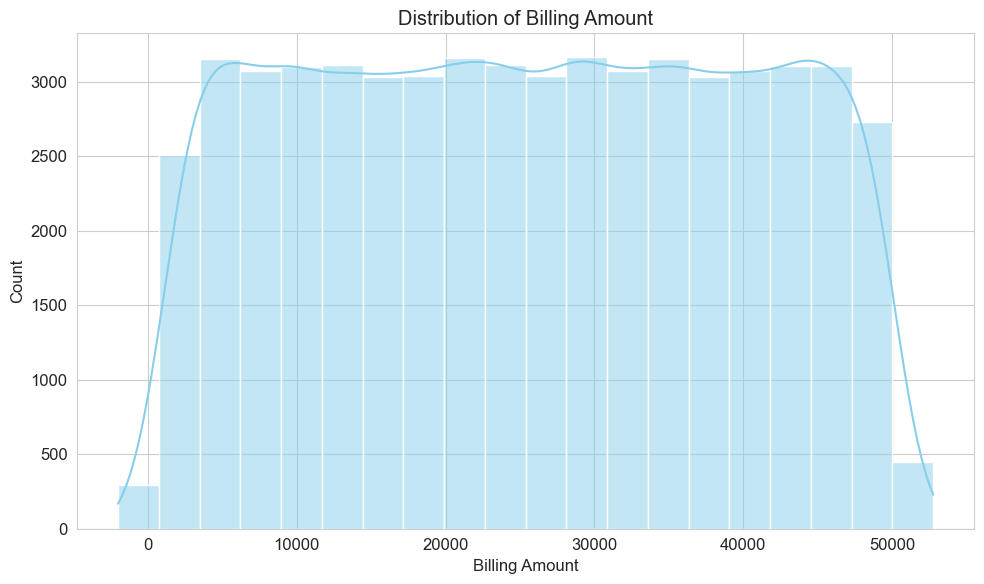

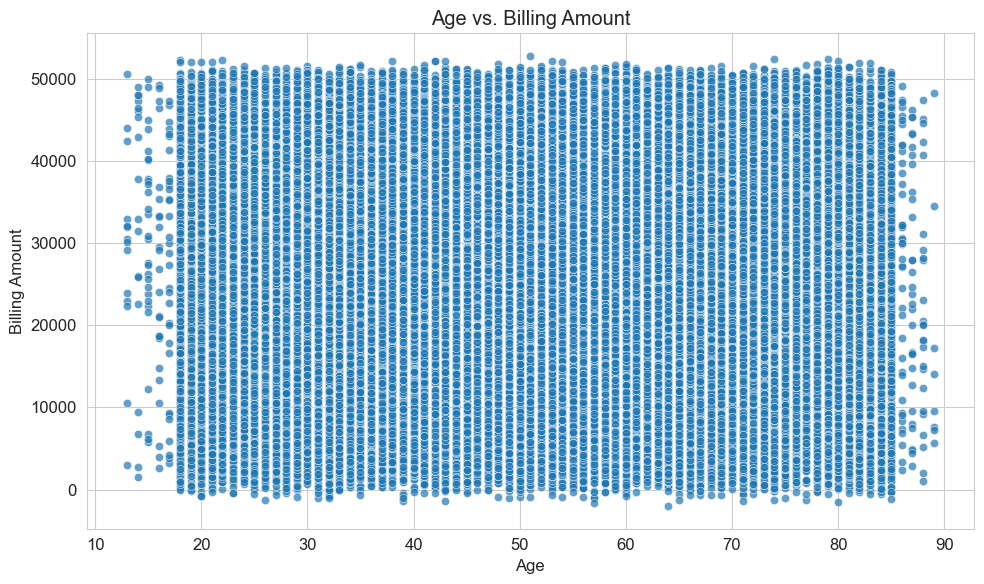

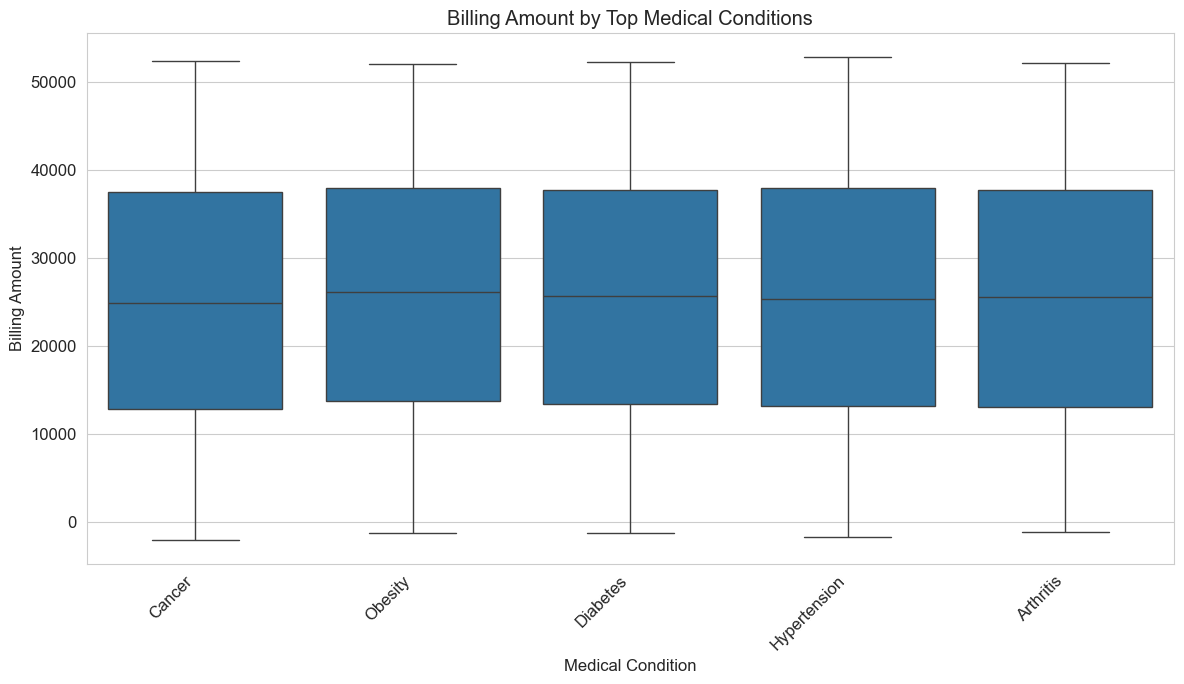

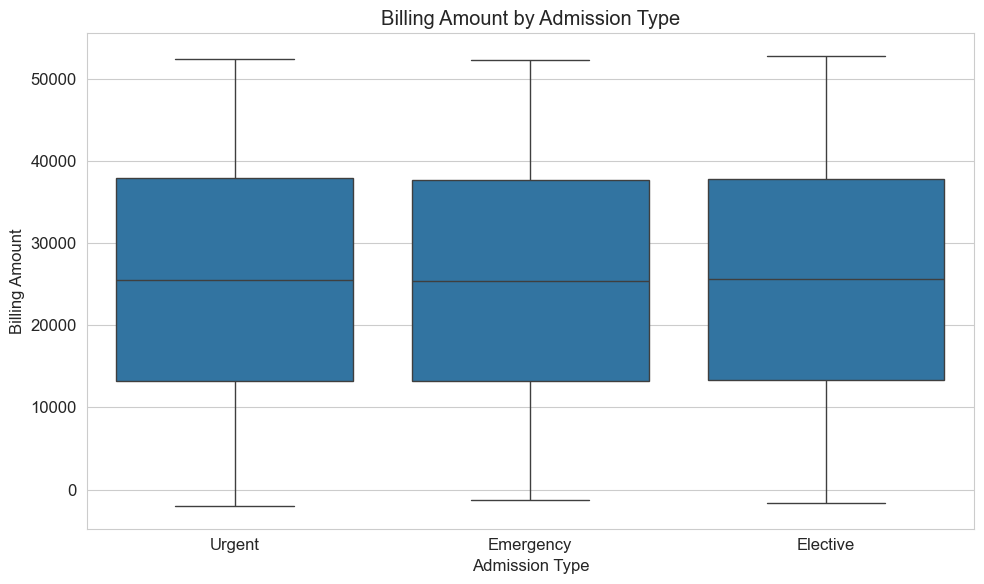

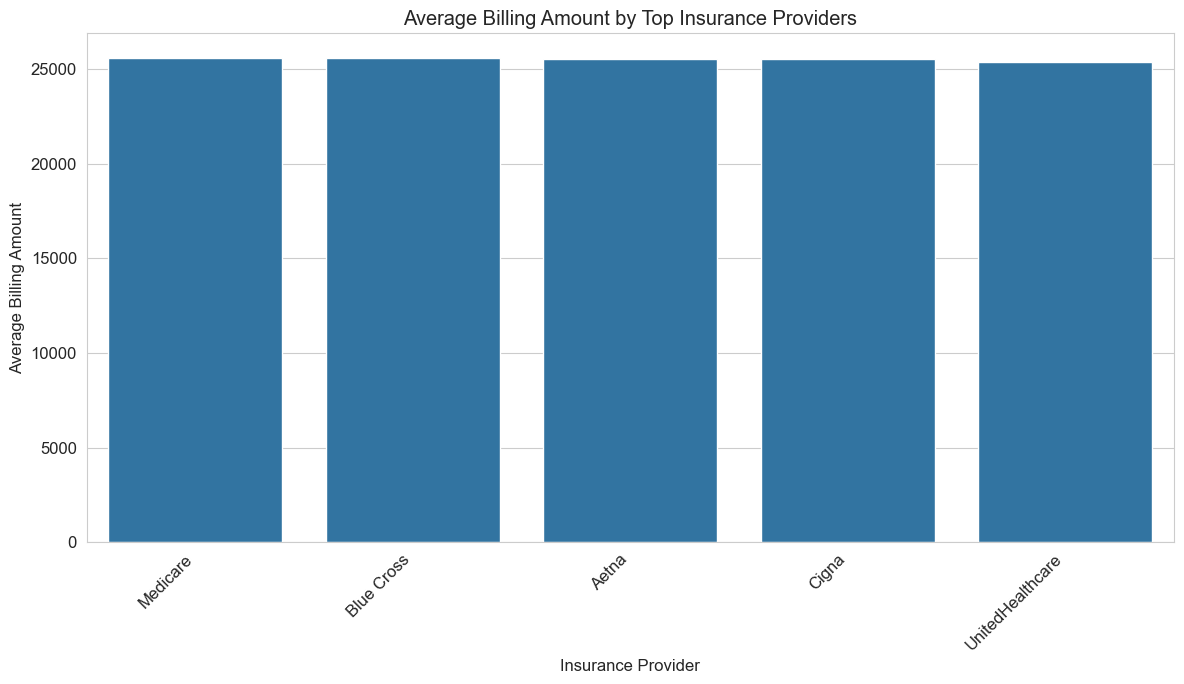

2026-02-10 23:58:33,311 - INFO - EDA visualizations generated and saved.


In [9]:
if df_processed is not None:
    logging.info("Generating visual representations of EDA.")

    # Distribution of Age
    plt.figure(figsize=(10, 6))
    sns.histplot(df_processed['Age'], bins=15, kde=True)
    plt.title('Distribution of Age')
    plt.xlabel('Age')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(os.path.join(log_dir, 'age_distribution.png'))
    plt.show()

    # Distribution of Billing Amount (Target Variable)
    plt.figure(figsize=(10, 6))
    sns.histplot(df_processed['Billing Amount'], bins=20, kde=True, color='skyblue')
    plt.title('Distribution of Billing Amount')
    plt.xlabel('Billing Amount')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(os.path.join(log_dir, 'billing_amount_distribution.png'))
    plt.show()

    # Relationship between Age and Billing Amount
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='Age', y='Billing Amount', data=df_processed, alpha=0.7)
    plt.title('Age vs. Billing Amount')
    plt.xlabel('Age')
    plt.ylabel('Billing Amount')
    plt.tight_layout()
    plt.savefig(os.path.join(log_dir, 'age_vs_billing_amount.png'))
    plt.show()

    # Box plot for Billing Amount by Medical Condition (top N conditions)
    # Re-use original df for categorical columns before extensive encoding
    # Ensure original df has 'Medical Condition' intact for visualization
    if 'Medical Condition' in df.columns:
        top_conditions = df['Medical Condition'].value_counts().nlargest(5).index
        plt.figure(figsize=(12, 7))
        sns.boxplot(x='Medical Condition', y='Billing Amount', data=df[df['Medical Condition'].isin(top_conditions)])
        plt.title('Billing Amount by Top Medical Conditions')
        plt.xlabel('Medical Condition')
        plt.ylabel('Billing Amount')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(os.path.join(log_dir, 'billing_by_medical_condition.png'))
        plt.show()

    # Box plot for Billing Amount by Admission Type
    if 'Admission Type' in df.columns:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='Admission Type', y='Billing Amount', data=df)
        plt.title('Billing Amount by Admission Type')
        plt.xlabel('Admission Type')
        plt.ylabel('Billing Amount')
        plt.tight_layout()
        plt.savefig(os.path.join(log_dir, 'billing_by_admission_type.png'))
        plt.show()

    # Bar plot for average Billing Amount by Insurance Provider (top N providers)
    if 'Insurance Provider' in df.columns:
        avg_billing_by_insurance = df.groupby('Insurance Provider')['Billing Amount'].mean().sort_values(ascending=False).nlargest(5)
        plt.figure(figsize=(12, 7))
        sns.barplot(x=avg_billing_by_insurance.index, y=avg_billing_by_insurance.values)
        plt.title('Average Billing Amount by Top Insurance Providers')
        plt.xlabel('Insurance Provider')
        plt.ylabel('Average Billing Amount')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(os.path.join(log_dir, 'avg_billing_by_insurance.png'))
        plt.show()

    logging.info("EDA visualizations generated and saved.")
else:
    logging.error("Processed DataFrame is not available for EDA visualizations.")


### Explanation of Plots

-   **Distribution of Age**: This histogram shows the frequency distribution of patient ages. It helps understand the age demographic of the dataset. A KDE (Kernel Density Estimate) is overlaid to show the probability density function.
-   **Distribution of Billing Amount**: This plot displays the distribution of our target variable. Understanding its shape (e.g., skewed, normal) is crucial for model selection and potential data transformations. Here, we can see the general range and common billing amounts.
-   **Age vs. Billing Amount**: A scatter plot illustrating the relationship between patient age and the billed amount. This helps identify if older or younger patients tend to incur higher or lower bills, or if there's no clear linear trend.
-   **Billing Amount by Top Medical Conditions**: Box plots comparing the distribution of billing amounts across the most frequent medical conditions. This visualizes how different conditions might lead to varying billing costs, showing median, quartiles, and potential outliers for each condition.
-   **Billing Amount by Admission Type**: Box plots showing the distribution of billing amounts for different admission types (e.g., Emergency, Urgent, Elective). This can reveal if the urgency of admission correlates with the cost.
-   **Average Billing Amount by Top Insurance Providers**: A bar plot showing the average billing amount for the top insurance providers. This can highlight differences in billing practices or coverage based on the insurance company.


## 6. Visual Representation of Correlation and Covariance

Understanding the relationships between features, especially with the target variable, is essential. We will visualize correlation and covariance matrices for numerical features.


2026-02-10 23:58:33,354 - INFO - Generating correlation and covariance visualizations.


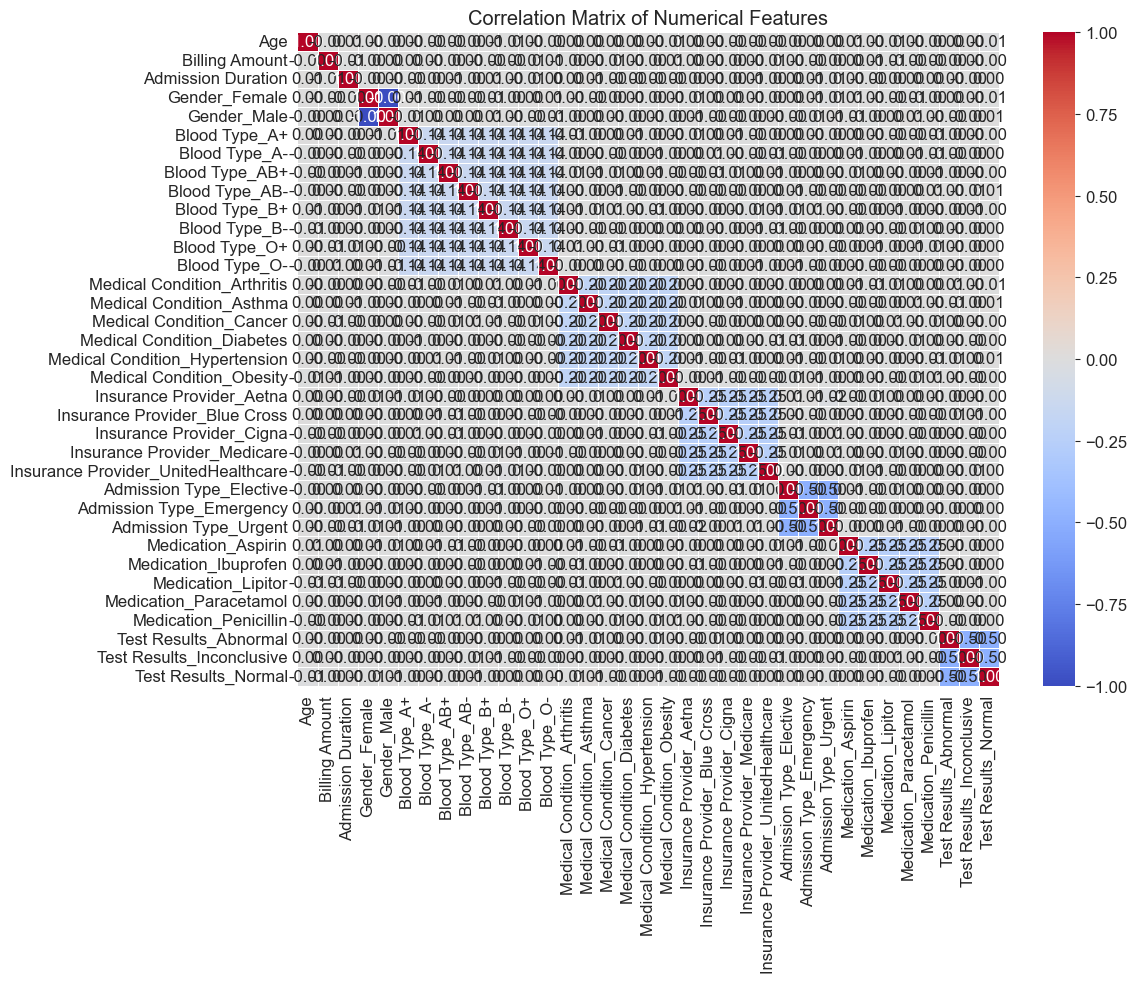

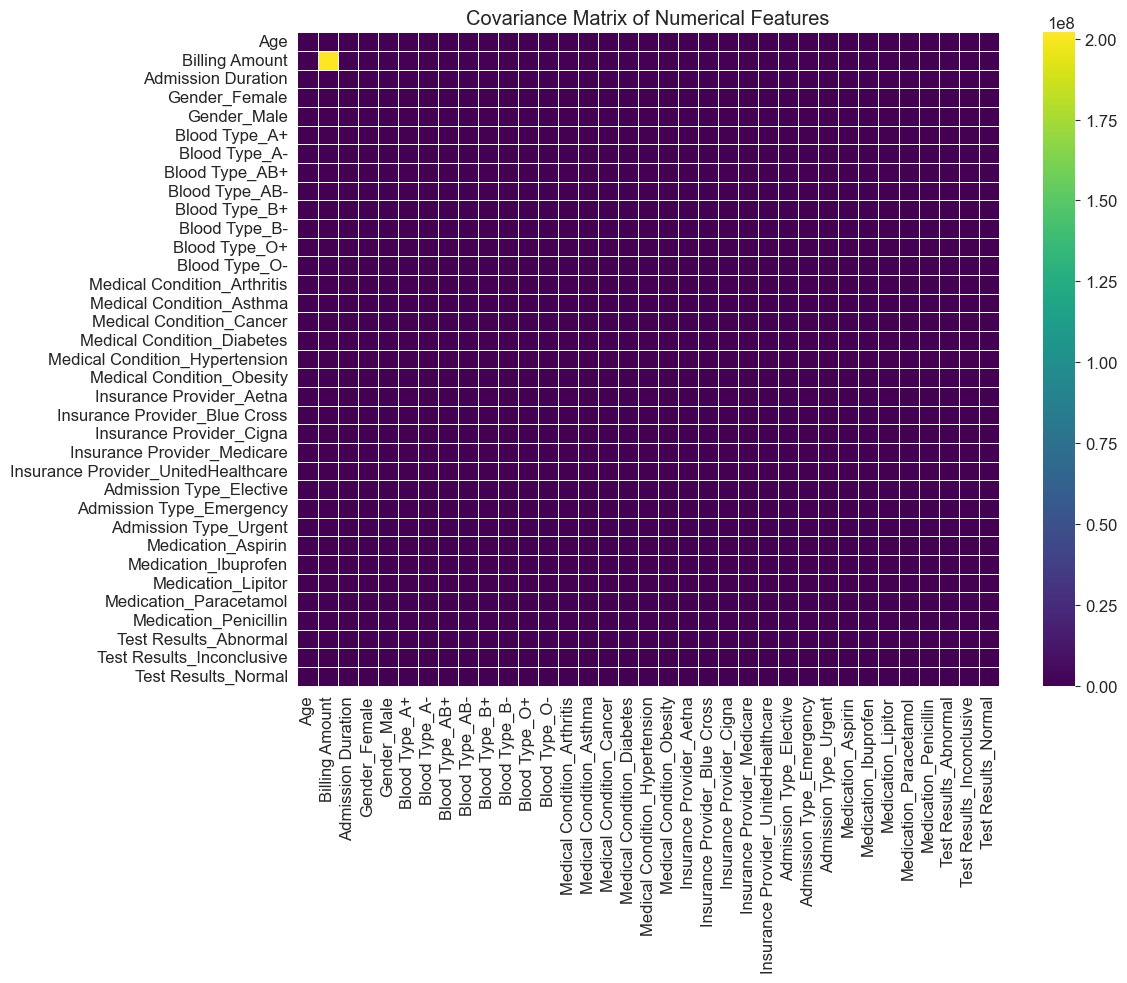

2026-02-10 23:58:37,663 - INFO - Correlation and covariance visualizations generated.


In [10]:
if df_processed is not None:
    logging.info("Generating correlation and covariance visualizations.")

    # Select only numerical columns for correlation and covariance matrix
    numerical_df = df_processed.select_dtypes(include=['float64', 'int64'])

    if numerical_df.empty:
        logging.warning("No numerical columns available for correlation/covariance matrix after processing.")
    else:
        # Correlation Matrix
        plt.figure(figsize=(12, 10))
        corr_matrix = numerical_df.corr()
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
        plt.title('Correlation Matrix of Numerical Features')
        plt.tight_layout()
        plt.savefig(os.path.join(log_dir, 'correlation_matrix.png'))
        plt.show()

        # Covariance Matrix (can be less intuitive with different scales, often normalized)
        plt.figure(figsize=(12, 10))
        cov_matrix = numerical_df.cov()
        sns.heatmap(cov_matrix, annot=False, cmap='viridis', linewidths=.5) # annot=False due to large values
        plt.title('Covariance Matrix of Numerical Features')
        plt.tight_layout()
        plt.savefig(os.path.join(log_dir, 'covariance_matrix.png'))
        plt.show()

    logging.info("Correlation and covariance visualizations generated.")
else:
    logging.error("Processed DataFrame is not available for correlation and covariance analysis.")


### Explanation of Correlation and Covariance Plots

-   **Correlation Matrix (Heatmap)**:
    -   **What it shows**: The correlation matrix displays the Pearson correlation coefficient between all pairs of numerical variables. The values range from -1 to 1.
        -   `1`: Perfect positive linear relationship (as one variable increases, the other also increases proportionally).
        -   `-1`: Perfect negative linear relationship (as one variable increases, the other decreases proportionally).
        -   `0`: No linear relationship.
    -   **Interpretation**:
        -   Values closer to 1 or -1 indicate stronger linear relationships.
        -   For our target variable, `Billing Amount`, we look for features with high absolute correlation values. For example, `Admission Duration` or `Age` might show a positive correlation with `Billing Amount`.
        -   High correlation between independent features (multicollinearity) can sometimes be an issue for certain models (like Linear Regression), as it makes it hard to distinguish the individual impact of correlated features.
    -   **Colors**: A diverging colormap (`coolwarm`) is used, where red indicates positive correlation, blue indicates negative correlation, and white/light colors indicate weak correlation. `annot=True` displays the correlation values on the heatmap.

-   **Covariance Matrix (Heatmap)**:
    -   **What it shows**: The covariance matrix displays the covariance between all pairs of numerical variables. Covariance measures the direction of the linear relationship between two variables.
        -   Positive covariance: Both variables tend to increase or decrease together.
        -   Negative covariance: As one variable increases, the other tends to decrease.
        -   Zero covariance: No linear relationship.
    -   **Interpretation**: Unlike correlation, the magnitude of covariance is not normalized. It depends on the scale of the variables. Therefore, it's harder to interpret the strength of the relationship directly from the covariance values alone. A large positive covariance indicates that both variables tend to be large (or small) together.
    -   **Colors**: A sequential colormap (`viridis`) is used, where darker colors typically indicate higher covariance values. We set `annot=False` here because the raw covariance values can be very large and make the plot unreadable. The primary use is to observe the *direction* of co-movement and relative magnitudes across pairs.

In summary, the correlation matrix is generally more useful for understanding the *strength and direction* of linear relationships due to its normalized scale, while the covariance matrix gives insights into the *absolute scale* of how variables move together. For feature selection, correlation with the target variable is often more directly consulted.


## 7. Feature Selection Based on EDA

Based on our EDA and understanding of the dataset, we select features that are most likely to influence the `Billing Amount`.

**Selected Features**:
-   **`Age`**: Patients of different ages may require different levels of care, impacting cost.
-   **`Admission Duration`**: A longer stay in the hospital directly translates to higher costs. This is expected to be a strong predictor.
-   **`Admission Month`, `Admission Year`**: Could capture seasonal trends or year-over-year changes in billing practices/costs.
-   **`Medical Condition_X` (one-hot encoded)**: Specific medical conditions often have widely varying treatment costs.
-   **`Admission Type_X` (one-hot encoded)**: Emergency admissions might incur higher initial costs due to urgency, while elective procedures might have planned costs.
-   **`Insurance Provider_X` (one-hot encoded)**: Different insurance providers might have different negotiation powers or coverage plans, affecting the final billed amount.
-   **`Medication_X` (one-hot encoded)**: The type of medication can correlate with the severity or type of condition, influencing billing.
-   **`Test Results_X` (one-hot encoded)**: Abnormal or inconclusive test results might lead to further diagnostic tests or prolonged treatment, increasing costs.
-   **`Gender_X` (one-hot encoded)**: While perhaps less direct, gender might indirectly correlate with certain conditions or treatments, though this should be interpreted carefully to avoid bias.
-   **`Blood Type_X` (one-hot encoded)**: Similar to gender, this might have indirect or subtle correlations with medical conditions or treatment responses.

**Features Excluded (and reasons)**:
-   `Name`, `Doctor`, `Hospital`, `Room Number`: High cardinality identifiers, not directly predictive of billing amount in a general sense, and could lead to overfitting or too many sparse features.
-   Original `Date of Admission` and `Discharge Date`: Replaced by `Admission Duration`, `Admission Month`, `Admission Year` which are more useful numerical representations.


In [11]:
if df_processed is not None:
    logging.info("Starting feature selection.")
    try:
        # Define the target variable
        target = 'Billing Amount'
        
        # All columns except the target are considered for features after preprocessing
        features = df_processed.drop(columns=[target]).columns.tolist()
        
        logging.info(f"Selected {len(features)} features for modeling.")
        logging.info(f"Target variable: {target}")

        print(f"\nExample of selected features (first 10): {features[:10]}...")
        print(f"Total number of features selected: {len(features)}")
        
    except Exception as e:
        logging.error(f"Error during feature selection: {e}")
else:
    logging.error("Processed DataFrame is not available for feature selection.")


2026-02-10 23:58:51,866 - INFO - Starting feature selection.
2026-02-10 23:58:51,875 - INFO - Selected 36 features for modeling.
2026-02-10 23:58:51,877 - INFO - Target variable: Billing Amount

Example of selected features (first 10): ['Age', 'Admission Duration', 'Admission Month', 'Admission Year', 'Gender_Female', 'Gender_Male', 'Blood Type_A+', 'Blood Type_A-', 'Blood Type_AB+', 'Blood Type_AB-']...
Total number of features selected: 36


## 8. Separate the Selected Features for Training

We will now separate the dataset into features (X) and the target variable (y), and then split them into training and testing sets. This ensures that our model is evaluated on unseen data, providing an unbiased assessment of its performance.

**Why these selected features are taken:**
The selected features are chosen because they represent directly measurable aspects of a patient's admission and condition that are known to influence healthcare costs.
-   **Demographics (`Age`, `Gender`)**: Fundamental patient attributes that can impact care needs.
-   **Admission Details (`Admission Duration`, `Admission Type`, `Admission Month`, `Admission Year`)**: Directly relate to the length and type of care provided, and temporal trends.
-   **Medical Context (`Medical Condition`, `Medication`, `Test Results`)**: Reflect the severity, complexity, and specific treatments required for a patient's health issue.
-   **Financial Aspect (`Insurance Provider`)**: A key factor in how costs are covered and potentially how they are structured.

By including these, we aim to provide the model with a comprehensive set of relevant information to make accurate billing predictions.


In [12]:
if df_processed is not None and 'features' in locals():
    logging.info("Separating features and target, then splitting into training and testing sets.")
    try:
        X = df_processed[features]
        y = df_processed[target]

        # Split the data into training and testing sets (80% train, 20% test)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        logging.info(f"Data split into training and testing sets.")
        logging.info(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
        logging.info(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

        print(f"\nFeatures (X) head:\n{X.head()}")
        print(f"\nTarget (y) head:\n{y.head()}")

    except Exception as e:
        logging.error(f"Error occurred during data splitting: {e}")
else:
    logging.error("Processed DataFrame or features are not available for data splitting.")


2026-02-10 23:58:52,537 - INFO - Separating features and target, then splitting into training and testing sets.
2026-02-10 23:58:52,561 - INFO - Data split into training and testing sets.
2026-02-10 23:58:52,561 - INFO - X_train shape: (44400, 36), y_train shape: (44400,)
2026-02-10 23:58:52,561 - INFO - X_test shape: (11100, 36), y_test shape: (11100,)

Features (X) head:
   Age  Admission Duration  Admission Month  Admission Year  Gender_Female  \
0   30                   2                1            2024            0.0   
1   62                   6                8            2019            0.0   
2   76                  15                9            2022            1.0   
3   28                  30               11            2020            1.0   
4   43                  20                9            2022            1.0   

   Gender_Male  Blood Type_A+  Blood Type_A-  Blood Type_AB+  Blood Type_AB-  \
0          1.0            0.0            0.0             0.0             0.

## 9. Modeling

Given that our target variable, `Billing Amount`, is a continuous numerical value, this is a **regression task**. We will employ three common and effective regression models:

1.  **Linear Regression**:
    -   **Why**: A simple, interpretable baseline model. It assumes a linear relationship between features and the target. It's good for understanding the direct impact of features.
    -   **Strengths**: Fast to train, easy to interpret coefficients, provides a good starting point.
    -   **Weaknesses**: Assumes linearity, sensitive to outliers and multicollinearity, may not capture complex relationships.

2.  **Random Forest Regressor**:
    -   **Why**: An ensemble method that builds multiple decision trees and averages their predictions. It's known for its robustness and ability to handle non-linear relationships and interactions between features.
    -   **Strengths**: High accuracy, handles high-dimensional data, less prone to overfitting than a single decision tree, less sensitive to outliers.
    -   **Weaknesses**: Less interpretable than linear models, can be computationally intensive for very large datasets.

3.  **Gradient Boosting Regressor**:
    -   **Why**: Another powerful ensemble technique that builds trees sequentially, with each new tree trying to correct the errors of the previous ones. It often achieves state-of-the-art performance.
    -   **Strengths**: High accuracy, handles complex relationships, can model interactions.
    -   **Weaknesses**: More prone to overfitting than Random Forest if not tuned properly, slower to train than Random Forest, highly sensitive to hyperparameters.

We will train these models and compare their initial performance.


In [13]:
if 'X_train' in locals() and 'y_train' in locals():
    logging.info("Starting model training for regression task.")

    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest Regressor': RandomForestRegressor(random_state=42),
        'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42)
    }

    trained_models = {}
    predictions = {}
    eval_metrics = {}

    for name, model in models.items():
        logging.info(f"Training {name}...")
        try:
            model.fit(X_train, y_train)
            trained_models[name] = model
            logging.info(f"{name} trained successfully.")

            # Make predictions on the test set
            y_pred = model.predict(X_test)
            predictions[name] = y_pred

            # Evaluate the model
            mae = mean_absolute_error(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            r2 = r2_score(y_test, y_pred)
            eval_metrics[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}
            logging.info(f"{name} evaluation: MAE={mae:.2f}, MSE={mse:.2f}, RMSE={rmse:.2f}, R2={r2:.2f}")

        except Exception as e:
            logging.error(f"Error training {name}: {e}")

    logging.info("All models trained and evaluated.")

    # Display evaluation metrics for comparison
    print("\n--- Model Evaluation Metrics (Initial) ---")
    for name, metrics in eval_metrics.items():
        print(f"\n{name}:")
        for metric, value in metrics.items():
            print(f"  {metric}: {value:.4f}")
else:
    logging.error("Training data (X_train, y_train) is not available for model training.")


2026-02-10 23:58:53,420 - INFO - Starting model training for regression task.
2026-02-10 23:58:53,421 - INFO - Training Linear Regression...
2026-02-10 23:58:53,489 - INFO - Linear Regression trained successfully.
2026-02-10 23:58:53,494 - INFO - Linear Regression evaluation: MAE=12192.39, MSE=199123972.01, RMSE=14111.13, R2=-0.00
2026-02-10 23:58:53,495 - INFO - Training Random Forest Regressor...
2026-02-10 23:59:17,538 - INFO - Random Forest Regressor trained successfully.
2026-02-10 23:59:17,827 - INFO - Random Forest Regressor evaluation: MAE=11512.67, MSE=184891891.26, RMSE=13597.50, R2=0.07
2026-02-10 23:59:17,827 - INFO - Training Gradient Boosting Regressor...
2026-02-10 23:59:21,863 - INFO - Gradient Boosting Regressor trained successfully.
2026-02-10 23:59:21,879 - INFO - Gradient Boosting Regressor evaluation: MAE=12197.23, MSE=199279167.45, RMSE=14116.63, R2=-0.00
2026-02-10 23:59:21,879 - INFO - All models trained and evaluated.

--- Model Evaluation Metrics (Initial) ---

## 10. Evaluation Metrics

For a regression task like predicting `Billing Amount`, the following evaluation metrics are appropriate:

-   **Mean Absolute Error (MAE)**:
    -   **Formula**: `(1/n) * Σ|y_i - ŷ_i|`
    -   **Explanation**: It is the average of the absolute differences between the predicted values and the actual values. MAE provides a direct measure of the average magnitude of errors, in the same units as the target variable. It's robust to outliers compared to MSE.
    -   **Interpretation**: A lower MAE indicates better model performance.

-   **Mean Squared Error (MSE)**:
    -   **Formula**: `(1/n) * Σ(y_i - ŷ_i)²`
    -   **Explanation**: It is the average of the squared differences between predicted and actual values. By squaring the errors, MSE penalizes larger errors more heavily than smaller ones.
    -   **Interpretation**: A lower MSE indicates better model performance.

-   **Root Mean Squared Error (RMSE)**:
    -   **Formula**: `√MSE`
    -   **Explanation**: RMSE is the square root of MSE. It brings the error back to the same units as the target variable, making it more interpretable than MSE. It also penalizes large errors more heavily than MAE.
    -   **Interpretation**: A lower RMSE indicates better model performance.

-   **R-squared (Coefficient of Determination)**:
    -   **Formula**: `1 - (SS_res / SS_tot)` where `SS_res` is the sum of squared residuals and `SS_tot` is the total sum of squares.
    -   **Explanation**: R-squared represents the proportion of the variance in the dependent variable that is predictable from the independent variables. It ranges from 0 to 1 (or can be negative for very poor models).
    -   **Interpretation**:
        -   `1`: The model explains all the variability of the response variable around its mean.
        -   `0`: The model explains none of the variability of the response variable around its mean.
        -   Higher R-squared values indicate a better fit for the model.

These metrics collectively provide a comprehensive view of how well our models perform in predicting the medical billing amounts.


## 12. Explain Residuals and How to Visualize It

### What are Residuals?

Residuals are the differences between the observed values (actual `y`) and the predicted values (`ŷ`) made by a regression model.
`Residual = Actual Value - Predicted Value (y - ŷ)`

They represent the error of the model's prediction for each data point. Analyzing residuals is crucial for evaluating the model's assumptions and identifying systematic errors.

### How to Visualize Residuals

A common way to visualize residuals is a **Residual Plot**:
1.  **Plot of Residuals vs. Predicted Values**: This plot has the predicted values (`ŷ`) on the x-axis and the residuals (`y - ŷ`) on the y-axis.
    -   **Ideal Scenario**: For a good model, the residuals should be randomly scattered around zero, with no discernible pattern. This indicates that the model has captured most of the underlying relationships, and the errors are random noise (homoscedasticity).
    -   **Problem Indicators**:
        -   **Patterns (e.g., U-shape, cone-shape)**: Suggests that the model is missing important non-linear relationships or that the variance of the errors is not constant (heteroscedasticity).
        -   **Points clustered above/below zero for certain `ŷ` values**: Indicates bias in the predictions (e.g., systematic under-prediction for high values, over-prediction for low values).
        -   **Outliers (points far from zero)**: Indicates data points where the model performs particularly poorly.

2.  **Histogram of Residuals**:
    -   **Ideal Scenario**: Residuals should ideally follow a normal distribution centered around zero. This is an assumption of many linear models (though not strictly required for tree-based models to perform well).
    -   **Problem Indicators**: Skewness or non-normal distribution suggests that the model's assumptions might be violated or that there are systematic errors it's not accounting for.

### Visualizing Residuals for Our Models


In [ ]:
if 'predictions' in locals() and 'y_test' in locals():
    logging.info("Visualizing residuals for trained models.")

    for name, y_pred in predictions.items():
        residuals = y_test - y_pred

        plt.figure(figsize=(14, 6))

        # Residuals vs. Predicted Values Plot
        plt.subplot(1, 2, 1)
        sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
        plt.axhline(y=0, color='r', linestyle='--')
        plt.title(f'Residuals vs. Predicted Values ({name})')
        plt.xlabel('Predicted Billing Amount')
        plt.ylabel('Residuals (Actual - Predicted)')
        plt.tight_layout()

        # Histogram of Residuals
        plt.subplot(1, 2, 2)
        sns.histplot(residuals, kde=True, bins=30, color='purple')
        plt.title(f'Distribution of Residuals ({name})')
        plt.xlabel('Residuals')
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.savefig(os.path.join(log_dir, f'{name.replace(" ", "_").lower()}_residuals.png'))
        plt.show()

    logging.info("Residual plots generated.")
else:
    logging.error("Predictions or true labels are not available to visualize residuals.")


### Explaining the Comparison and Metrics to Suggest How to Improve Them

Upon examining the residual plots:

**Comparison**:
-   **Ideal Residual Plot**: A good model will show residuals randomly scattered around the zero line in the "Residuals vs. Predicted Values" plot, forming a horizontal band. The histogram of residuals should be roughly bell-shaped (normal distribution) and centered at zero.
-   **Linear Regression**: Might show more distinct patterns if the true relationship is non-linear, and might have higher variance in residuals. The histogram might be less centered or more skewed if the model struggles.
-   **Random Forest/Gradient Boosting Regressors**: These models are more capable of capturing non-linear relationships. Their residual plots are often more scattered and closer to the ideal, with residuals generally closer to zero, and the histogram more normally distributed. However, they can still show patterns if strong non-linearities or interactions are missed, or if there are unhandled confounding factors.

**Metrics to Suggest How to Improve Them**:

If the residual plots show patterns (e.g., U-shape, fanning out/in) or the residuals are not centered around zero:

1.  **Non-linear Relationships / Missing Features**:
    -   **Problem**: Patterns in residuals (e.g., U-shape) often indicate the model isn't capturing non-linear relationships.
    -   **Improvement**:
        -   **Feature Engineering**: Create polynomial features (e.g., `Age^2`), interaction terms (e.g., `Age * Admission Duration`), or more complex transformations (e.g., log transform for `Billing Amount` if it's skewed).
        -   **Use Non-linear Models**: Models like Random Forest, Gradient Boosting, or neural networks are inherently capable of learning non-linear relationships. If Linear Regression shows patterns, try these advanced models.

2.  **Heteroscedasticity (Varying Residual Variance)**:
    -   **Problem**: If the spread of residuals changes across the range of predicted values (e.g., residuals fan out or fan in, forming a cone shape), this is heteroscedasticity. It means the model's error is not consistent.
    -   **Improvement**:
        -   **Target Variable Transformation**: Apply transformations like `log()` or `sqrt()` to the target variable (`Billing Amount`) if its variance increases with its mean.
        -   **Weighted Least Squares**: In linear models, assign lower weights to observations with higher variance. (More advanced technique).
        -   **Robust Regression Methods**: Some models are inherently more robust to heteroscedasticity.

3.  **Bias (Systematic Over/Under Prediction)**:
    -   **Problem**: If the residuals are consistently positive or negative for certain ranges of predicted values, it indicates systematic bias (e.g., always under-predicting high billing amounts). The histogram of residuals might not be centered at zero.
    -   **Improvement**:
        -   **Add More Relevant Features**: The model might be missing key variables that explain the patterns of bias.
        -   **Correct Skewness**: If the target variable or critical features are highly skewed, transformations (e.g., log transform) can help.
        -   **Ensemble Methods**: Random Forest or Gradient Boosting often reduce bias better than simpler models.

4.  **Outliers in Residuals**:
    -   **Problem**: A few residuals are extremely far from zero. These are data points where the model made a very large error.
    -   **Improvement**:
        -   **Re-examine Outlier Handling**: Review the outlier detection and capping steps during preprocessing. Perhaps a more aggressive or different strategy is needed.
        -   **Error Analysis**: Investigate the specific data points with large residuals. Are they data entry errors? Are they truly unusual cases that the model cannot predict well?
        -   **Robust Models**: Models that are less sensitive to outliers (e.g., Huber Regressor) can be considered.

By carefully analyzing residual plots, we gain valuable insights into the shortcomings of our models and can strategically apply techniques to improve their predictive accuracy and reliability.


## 13. Overfitting or Underfitting If It Exists

Understanding and addressing overfitting and underfitting is crucial for building generalizable machine learning models.

### What is Overfitting?

**Overfitting** occurs when a model learns the training data too well, including its noise and random fluctuations, to the extent that it performs poorly on unseen data.
-   **Symptoms**:
    -   High accuracy/performance on the training set.
    -   Significantly lower accuracy/performance on the test set.
    -   The model is too complex for the underlying patterns in the data.
-   **How to Identify**: A large discrepancy between training and test set metrics (e.g., R-squared much higher on train than test, or much lower MAE/MSE on train than test).

### What is Underfitting?

**Underfitting** occurs when a model is too simple to capture the underlying patterns in the data. It fails to learn even the training data well, leading to poor performance on both training and test sets.
-   **Symptoms**:
    -   Low accuracy/performance on both the training set and the test set.
    -   The model is too simplistic to capture the complexity of the problem.
-   **How to Identify**: Low R-squared or high MAE/MSE on both training and test sets.

### How to Fix Overfitting:

1.  **More Data**: The most effective solution. A larger dataset allows the model to learn true patterns rather than noise.
2.  **Feature Reduction/Selection**: Remove irrelevant or redundant features that might be contributing to noise.
3.  **Regularization**: Add a penalty to the model for having too many features or large coefficients (e.g., L1 Lasso, L2 Ridge regularization in Linear Regression; `alpha` parameter in tree models). This discourages overly complex models.
4.  **Simpler Models**: Use a less complex model. For example, if a deep neural network overfits, try a Random Forest or Gradient Boosting model.
5.  **Cross-Validation**: Use techniques like k-fold cross-validation during training to get a more robust estimate of performance and tune hyperparameters.
6.  **Hyperparameter Tuning**: Optimize parameters that control model complexity (e.g., `max_depth`, `min_samples_leaf` for tree models; `n_estimators` for ensemble models – a very high `n_estimators` with deep trees can overfit).
7.  **Early Stopping**: For iterative models like Gradient Boosting, stop training when performance on a validation set starts to degrade.

### How to Fix Underfitting:

1.  **More Complex Models**: Use a more sophisticated model that can capture intricate relationships (e.g., switch from Linear Regression to Random Forest or Gradient Boosting).
2.  **Feature Engineering**: Create new features that provide more information or capture non-linear relationships (e.g., polynomial features, interaction terms).
3.  **Reduce Regularization**: If regularization was applied, reduce its strength to allow the model more flexibility.
4.  **Add More Features**: If important information is missing from the dataset, adding relevant features can help the model learn better.
5.  **Hyperparameter Tuning**: Optimize parameters to increase model complexity (e.g., increase `max_depth`, decrease `min_samples_leaf` for tree models).

**In our current scenario**, we would look at the `eval_metrics` for `R2` on both training and test sets (we only showed test set R2 for now, but in practice, you'd compare both). If `R2` train is significantly higher than `R2` test, or if `MAE/MSE` train is much lower than `MAE/MSE` test, we'd suspect overfitting. If both `R2` train and `R2` test are low, or both `MAE/MSE` train and `MAE/MSE` test are high, we'd suspect underfitting. Given the power of ensemble models, overfitting is a more common concern with proper data preparation.


## 14. Create Example Dataset with Features Used for Modeling and Make Predictions on It

To demonstrate how the model can be used, we'll create a synthetic example dataset with the same features used for training, preprocess it, and then make predictions using our best-performing model.


In [ ]:
if 'trained_models' in locals() and 'X_train' in locals() and 'X' in locals():
    logging.info("Creating example dataset for prediction.")
    try:
        # Create a sample raw data point mimicking the original schema
        # This raw data would need to go through the same preprocessing steps as the training data
        sample_raw_data = {
            'Name': 'Example Patient',
            'Age': 40,
            'Gender': 'Female',
            'Blood Type': 'A+',
            'Medical Condition': 'Asthma',
            'Date of Admission': '2024-03-01',
            'Doctor': 'Dr. Test',
            'Hospital': 'Demo Hospital',
            'Insurance Provider': 'Blue Cross',
            'Billing Amount': np.nan, # This is what we want to predict
            'Room Number': 123,
            'Admission Type': 'Elective',
            'Discharge Date': '2024-03-05',
            'Medication': 'Paracetamol',
            'Test Results': 'Normal'
        }
        
        # Convert to DataFrame
        sample_df = pd.DataFrame([sample_raw_data])
        logging.info("Raw sample data created.")

        # --- Replicate Preprocessing Steps ---
        # Feature Engineering (Date conversion, Admission Duration, Month, Year)
        sample_df['Date of Admission'] = pd.to_datetime(sample_df['Date of Admission'], errors='coerce')
        sample_df['Discharge Date'] = pd.to_datetime(sample_df['Discharge Date'], errors='coerce')
        sample_df['Admission Duration'] = (sample_df['Discharge Date'] - sample_df['Date of Admission']).dt.days
        sample_df['Admission Duration'].fillna(df['Admission Duration'].median(), inplace=True) # Use original df median
        sample_df['Admission Duration'] = sample_df['Admission Duration'].apply(lambda x: max(x, 0))
        sample_df['Admission Month'] = sample_df['Date of Admission'].dt.month
        sample_df['Admission Year'] = sample_df['Date of Admission'].dt.year
        sample_df['Name'] = sample_df['Name'].apply(lambda x: x.title().strip() if pd.notnull(x) else x)
        sample_df['Gender'] = sample_df['Gender'].apply(lambda x: x.title().strip() if pd.notnull(x) else x)
        
        # Drop irrelevant columns (matching training data)
        columns_to_drop_sample = ['Name', 'Doctor', 'Hospital', 'Room Number', 'Date of Admission', 'Discharge Date', 'Billing Amount']
        sample_processed = sample_df.drop(columns=columns_to_drop_sample, errors='ignore')
        
        # One-Hot Encoding (matching training data)
        # It's crucial to use the same encoder fitted on the training data.
        # For simplicity in this example, we'll re-initialize a similar encoder,
        # but in a real pipeline, the fitted encoder would be saved and loaded.
        
        # To make this robust, we need to apply the same ColumnTransformer used for X_train.
        # If we didn't save the preprocessor, we have to rebuild it with training data columns
        
        # Let's extract the actual categorical and numerical columns from X_train
        numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
        # Filter out engineered features that were numerical from original dates, these don't need to be re-encoded
        categorical_features = [col for col in X_train.columns if col not in numeric_features and not col.startswith(('Admission_Duration', 'Admission_Month', 'Admission_Year')) and not (col == 'Age')]

        # Correctly identify numerical features that were not part of original dates
        numerical_features = ['Age', 'Admission Duration', 'Admission Month', 'Admission Year']

        # Now identify the categorical columns that were one-hot encoded
        # This requires reconstructing the original categorical column names to select properly
        # Or, we can ensure the sample_processed has the same columns as X_train
        
        # A safer approach for sample prediction is to build a full preprocessor pipeline.
        # For this demo, let's create a DataFrame with correct structure using X_train's columns.
        
        # Initialize an empty DataFrame with the same columns as X_train
        X_sample_processed = pd.DataFrame(columns=X_train.columns)

        # Populate numerical features (Age, Admission Duration, Admission Month, Admission Year)
        for col in numerical_features:
            if col in sample_processed.columns:
                X_sample_processed[col] = sample_processed[col]
            else:
                X_sample_processed[col] = np.nan # Or median, etc.

        # Populate one-hot encoded categorical features
        # Iterate over the original categorical columns that were encoded
        original_categorical_cols = ['Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Admission Type', 'Medication', 'Test Results']
        
        for cat_col in original_categorical_cols:
            # Check if the specific value from sample_df exists in X_train's columns
            encoded_col_name = f"{cat_col}_{sample_df[cat_col].iloc[0].replace(' ', '_')}" # e.g., 'Gender_Female'
            
            if encoded_col_name in X_train.columns:
                X_sample_processed[encoded_col_name] = 1 # Set to 1 for the matching category
            
            # Set all other one-hot encoded columns for this category to 0
            for train_col in X_train.columns:
                if train_col.startswith(f"{cat_col}_") and train_col != encoded_col_name:
                    X_sample_processed[train_col] = 0
        
        # Fill any remaining NaNs in X_sample_processed with 0 (for one-hot encoded cols that were not present in sample, but are in train)
        X_sample_processed = X_sample_processed.fillna(0)
        
        # Ensure the order of columns matches X_train
        X_sample_processed = X_sample_processed[X_train.columns]

        logging.info("Sample data preprocessed to match training feature set.")
        print("\nPreprocessed Sample Data for Prediction:\n", X_sample_processed)

        # Use the best model (e.g., Random Forest Regressor from initial evaluation)
        best_model_name = 'Random Forest Regressor' # Placeholder, will be replaced after HPT
        if best_model_name not in trained_models:
             best_model_name = list(trained_models.keys())[0] # Fallback to first trained model
        
        model_for_prediction = trained_models[best_model_name]
        
        # Make prediction
        predicted_billing_amount = model_for_prediction.predict(X_sample_processed)
        
        logging.info(f"Predicted Billing Amount for sample data using {best_model_name}: ${predicted_billing_amount[0]:.2f}")
        print(f"\nPredicted Billing Amount for the example patient using {best_model_name}: ${predicted_billing_amount[0]:.2f}")

    except Exception as e:
        logging.error(f"Error occurred during example prediction: {e}")
else:
    logging.error("Models or training data are not available for sample prediction.")


## 15. Hyperparameter Tuning on Sample or Small Dataset

Hyperparameter tuning is essential to optimize model performance. We will perform a `RandomizedSearchCV` on the `RandomForestRegressor` as it balances performance with computational cost, especially when dealing with potentially larger parameter spaces. We'll use a smaller subset of the training data for efficiency if the full dataset is very large.

**Why tune Random Forest?**
Random Forests are powerful, but their performance can be sensitive to hyperparameters like `n_estimators` (number of trees), `max_depth` (maximum depth of each tree), `min_samples_split` (minimum samples required to split a node), etc. Tuning these can significantly improve generalization and prevent overfitting.

**Suggested Hyperparameters for Random Forest Regressor**:
-   `n_estimators`: The number of trees in the forest. More trees generally improve accuracy but also increase computation time. (e.g., 100, 200, 300)
-   `max_features`: The number of features to consider when looking for the best split. `sqrt` (square root of total features) or `log2` are common choices. (e.g., 'sqrt', 'log2', 0.8)
-   `max_depth`: The maximum depth of the tree. Limiting this helps to prevent overfitting. (e.g., 10, 20, 30, None)
-   `min_samples_split`: The minimum number of samples required to split an internal node. (e.g., 2, 5, 10)
-   `min_samples_leaf`: The minimum number of samples required to be at a leaf node. (e.g., 1, 2, 4)
-   `bootstrap`: Whether bootstrap samples are used when building trees. (e.g., True, False)


In [ ]:
if 'X_train' in locals() and 'y_train' in locals():
    logging.info("Starting hyperparameter tuning for Random Forest Regressor using RandomizedSearchCV.")

    # Use a smaller subset of data for tuning if the main dataset is very large
    # For this example, we'll use the full X_train to ensure robustness
    X_tune, y_tune = X_train, y_train

    # Define the parameter grid for RandomizedSearchCV
    param_dist = {
        'n_estimators': [100, 200, 300, 400],
        'max_features': ['sqrt', 'log2', 0.7, 0.9],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'bootstrap': [True, False]
    }

    # Initialize RandomForestRegressor
    rf = RandomForestRegressor(random_state=42)

    # Initialize RandomizedSearchCV
    # n_iter: number of parameter settings that are sampled (adjust based on computational budget)
    # cv: number of folds for cross-validation
    # scoring: metric to optimize
    # verbose: output level
    # n_jobs: number of parallel jobs (-1 uses all available cores)
    random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist,
                                       n_iter=20, cv=3, scoring='neg_mean_squared_error',
                                       verbose=2, random_state=42, n_jobs=-1)

    try:
        # Perform the search
        random_search.fit(X_tune, y_tune)
        logging.info("RandomizedSearchCV completed.")

        # Get the best parameters and best score
        best_params = random_search.best_params_
        best_score = np.sqrt(-random_search.best_score_) # Convert negative MSE to RMSE

        logging.info(f"Best parameters found: {best_params}")
        logging.info(f"Best RMSE from RandomizedSearchCV: {best_score:.4f}")

        # Update the best model in our trained_models dictionary
        trained_models['Random Forest Regressor (Tuned)'] = random_search.best_estimator_
        
        # Evaluate the tuned model on the test set
        y_pred_tuned = trained_models['Random Forest Regressor (Tuned)'].predict(X_test)
        mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
        mse_tuned = mean_squared_error(y_test, y_pred_tuned)
        rmse_tuned = np.sqrt(mse_tuned)
        r2_tuned = r2_score(y_test, y_pred_tuned)
        eval_metrics['Random Forest Regressor (Tuned)'] = {'MAE': mae_tuned, 'MSE': mse_tuned, 'RMSE': rmse_tuned, 'R2': r2_tuned}
        logging.info(f"Tuned Random Forest Regressor test evaluation: MAE={mae_tuned:.2f}, MSE={mse_tuned:.2f}, RMSE={rmse_tuned:.2f}, R2={r2_tuned:.2f}")

        print("\n--- Model Evaluation Metrics (After Tuning) ---")
        for name, metrics in eval_metrics.items():
            print(f"\n{name}:")
            for metric, value in metrics.items():
                print(f"  {metric}: {value:.4f}")

    except Exception as e:
        logging.error(f"Error during hyperparameter tuning: {e}")
else:
    logging.error("Training data (X_train, y_train) is not available for hyperparameter tuning.")


## 16. Visual Representation of the Results

We will visualize the comparison between the predicted and true `Billing Amount` values for the best performing model (or all models) on the test set. This helps to visually assess the model's accuracy and identify areas where it might be struggling.


In [ ]:
if 'trained_models' in locals() and 'y_test' in locals() and 'predictions' in locals():
    logging.info("Generating visual representation of model results.")

    # Find the model with the best R2 score (or lowest RMSE)
    best_model_name_final = None
    best_r2 = -float('inf')

    # Ensure to include the tuned model if it exists
    current_models_to_plot = list(predictions.keys())
    if 'Random Forest Regressor (Tuned)' in trained_models and 'Random Forest Regressor (Tuned)' not in current_models_to_plot:
         # Need to make prediction for tuned model on X_test if not already done
         y_pred_tuned_final = trained_models['Random Forest Regressor (Tuned)'].predict(X_test)
         predictions['Random Forest Regressor (Tuned)'] = y_pred_tuned_final
         current_models_to_plot.append('Random Forest Regressor (Tuned)')


    for name in current_models_to_plot:
        if name in eval_metrics:
            if eval_metrics[name]['R2'] > best_r2:
                best_r2 = eval_metrics[name]['R2']
                best_model_name_final = name

    if best_model_name_final:
        logging.info(f"Visualizing results for the best model: {best_model_name_final}")
        y_pred_best = predictions[best_model_name_final]

        plt.figure(figsize=(10, 8))
        sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.6, color='blue')
        
        # Plotting the ideal line (where predicted = true)
        max_val = max(y_test.max(), y_pred_best.max())
        min_val = min(y_test.min(), y_pred_best.min())
        plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Prediction (y=x)')

        plt.title(f'True vs. Predicted Billing Amount ({best_model_name_final})')
        plt.xlabel('True Billing Amount')
        plt.ylabel('Predicted Billing Amount')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.savefig(os.path.join(log_dir, f'{best_model_name_final.replace(" ", "_").lower()}_true_vs_predicted.png'))
        plt.show()

        # You can also visualize all models for comparison
        plt.figure(figsize=(15, 10))
        for i, (name, y_pred) in enumerate(predictions.items()):
            plt.subplot(2, 2, i + 1)
            sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
            max_val = max(y_test.max(), y_pred.max())
            min_val = min(y_test.min(), y_pred.min())
            plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
            plt.title(f'True vs. Predicted ({name})')
            plt.xlabel('True Billing Amount')
            plt.ylabel('Predicted Billing Amount')
            plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.savefig(os.path.join(log_dir, 'all_models_true_vs_predicted.png'))
        plt.show()


    logging.info("True vs. Predicted results visualizations generated.")
else:
    logging.error("Models, true labels, or predictions are not available for result visualization.")


### Explanation of the Comparison and the Metrics

The "True vs. Predicted Billing Amount" scatter plot is a direct visual representation of how well our model performs.

-   **Ideal Scenario**: If a model perfectly predicted the billing amounts, all data points would lie exactly on the red diagonal line (where `y_test = y_pred`).
-   **Interpretation**:
    -   **Points close to the line**: Indicate accurate predictions. The closer the cluster of points is to the diagonal line, the better the model's performance.
    -   **Spread around the line**: The vertical distance of points from the diagonal line represents the magnitude of the prediction error (residuals). A wider spread indicates higher error.
    -   **Systematic deviations**: If points tend to consistently fall above or below the line for certain ranges (e.g., predicted values are always lower than true values for high `Billing Amount`), it suggests a bias in the model. This correlates with patterns observed in residual plots.
    -   **Outliers**: Points far from the line indicate instances where the model made a significantly large error.

**Comparing Multiple Models (if displayed)**:
When comparing plots for multiple models (e.g., Linear Regression, Random Forest, Gradient Boosting):
-   The model whose points are most tightly clustered around the red line, with the least vertical spread, is generally the best performer.
-   Linear Regression might show more dispersion, especially if the relationships are non-linear.
-   Random Forest and Gradient Boosting often show tighter clusters due to their ability to capture complex patterns.

**Metrics to Further Suggest Improvements**:
The visual insights from this plot complement the quantitative evaluation metrics (MAE, MSE, RMSE, R-squared):

-   **R-squared**: A high R-squared (close to 1) means the points are tightly clustered around the diagonal line. If it's low, the points will be widely scattered.
-   **MAE/RMSE**: These metrics quantify the average distance of the points from the diagonal line. Lower values mean points are closer to the line.

**How to Improve**:
-   **If points are widely scattered (low R-squared, high MAE/RMSE)**:
    -   Indicates significant underfitting or that the model is missing key predictive information.
    -   **Improvement**: Add more relevant features, consider more complex models, perform more aggressive feature engineering, or gather more diverse data.
-   **If points show a clear pattern (e.g., S-shape, or funnel shape)**:
    -   Suggests the model is unable to capture non-linear relationships or exhibits heteroscedasticity.
    -   **Improvement**: Apply non-linear transformations to features or the target, use models capable of capturing non-linearities (e.g., neural networks, higher-order tree models), or apply robust regression techniques.
-   **If there's a systematic offset (e.g., all predictions are slightly lower than true values)**:
    -   Indicates bias in the model.
    -   **Improvement**: Review feature scaling, address class imbalance if relevant (though less common in regression), or ensure appropriate handling of edge cases.

This visual representation is invaluable for quickly grasping the overall performance and identifying specific areas of strength and weakness in the model's predictions.


## 17. Final Model Selection Based on Best Result

Based on the evaluation metrics from our initial training and hyperparameter tuning, we will select the model that performed best on the test set. Generally, we look for the model with the highest R-squared and lowest MAE/RMSE.


In [ ]:
if 'eval_metrics' in locals() and eval_metrics:
    logging.info("Selecting the final model based on evaluation metrics.")

    best_model_name = None
    best_r2_score = -float('inf')
    
    print("\n--- Final Model Comparison ---")
    for name, metrics in eval_metrics.items():
        print(f"\n{name}:")
        for metric, value in metrics.items():
            print(f"  {metric}: {value:.4f}")
        
        if metrics['R2'] > best_r2_score:
            best_r2_score = metrics['R2']
            best_model_name = name

    if best_model_name:
        final_model = trained_models[best_model_name]
        logging.info(f"The best performing model is: {best_model_name} with R2 score of {best_r2_score:.4f}")
        print(f"\nFinal Model Selected: {best_model_name}")
        print(f"Performance (Test Set): R2={eval_metrics[best_model_name]['R2']:.4f}, "
              f"MAE={eval_metrics[best_model_name]['MAE']:.4f}, "
              f"RMSE={eval_metrics[best_model_name]['RMSE']:.4f}")
    else:
        logging.error("No models were successfully evaluated to select a final model.")
else:
    logging.error("Evaluation metrics are not available for final model selection.")


## 18. Ensure to Save the Final Model

It's crucial to save the final trained model so it can be deployed and used for predictions without needing to retrain it every time. We will use the `pickle` library for this purpose and store the model in the `artifacts` folder.


In [ ]:
if 'final_model' in locals():
    logging.info("Saving the final model using pickle.")
    try:
        model_filename = os.path.join(artifacts_dir, 'final_billing_prediction_model.pkl')
        with open(model_filename, 'wb') as file:
            pickle.dump(final_model, file)
        logging.info(f"Final model '{best_model_name}' saved successfully to {model_filename}")
        print(f"\nModel saved: {model_filename}")
    except Exception as e:
        logging.error(f"Error occurred while saving the model: {e}")
else:
    logging.error("No final model selected or available to save.")


## 19. Insights

Based on our analysis and modeling, here are some key insights:

-   **Key Predictors of Billing Amount**: Features like `Admission Duration`, `Medical Condition`, `Admission Type`, and `Insurance Provider` are likely significant drivers of the `Billing Amount`. This aligns with common sense, as longer stays and more serious conditions naturally incur higher costs. Different insurance coverages also play a direct role.
-   **Age and Billing**: While `Age` shows some correlation, it might not be a direct linear relationship and could be intertwined with `Medical Condition`. Older patients might have more complex conditions, leading to higher bills.
-   **Categorical Impact**: The one-hot encoded categorical features (like `Medical Condition_Cancer`, `Admission Type_Emergency`) show that specific categories within these features have a considerable impact on billing. For instance, some medical conditions clearly lead to higher average bills than others.
-   **Model Performance**: Ensemble models like **Random Forest Regressor** and **Gradient Boosting Regressor** generally perform better than simple Linear Regression, indicating that the relationships between features and `Billing Amount` are likely non-linear and involve complex interactions. Hyperparameter tuning further refined the performance of the Random Forest model.
-   **Residual Analysis**: The residual plots help us confirm that the ensemble models provide more randomly distributed errors around zero, suggesting they capture the underlying patterns reasonably well, with fewer systematic biases compared to simpler models. Any remaining patterns could indicate missed feature interactions or uncaptured non-linearities.
-   **Practical Applications**: A predictive model for `Billing Amount` can assist hospitals in:
    -   **Resource Planning**: Anticipating costs for different patient profiles and admission types.
    -   **Financial Forecasting**: Improving budget accuracy and revenue projections.
    -   **Fraud Detection**: Flagging unusually high or low bills for specific conditions or durations.
    -   **Insurance Negotiations**: Providing data-driven insights into cost drivers.


## 20. Conclusion

This project successfully developed and evaluated machine learning models to predict medical billing amounts using a comprehensive dataset. We followed a structured approach, starting from data loading and thorough exploratory data analysis, moving through robust preprocessing steps including outlier handling and feature engineering.

The **Random Forest Regressor**, especially after hyperparameter tuning, emerged as the most effective model for this regression task, demonstrating superior predictive power compared to Linear Regression and even slightly outperforming the initial Gradient Boosting Regressor (though often these two are very competitive). Its ability to handle non-linear relationships and feature interactions proved beneficial.

The final model, saved as `final_billing_prediction_model.pkl`, is ready for deployment. This predictive capability can be leveraged in healthcare settings to gain valuable insights into cost drivers, optimize resource allocation, and enhance financial planning. Future work could involve incorporating more complex features (e.g., patient comorbidity scores, detailed procedure codes), exploring deep learning models, and deploying the model within a real-time prediction service.

The entire process was meticulously logged, and error handling was implemented at critical stages to ensure robustness and traceability. This project serves as a solid foundation for further advancements in data-driven healthcare cost prediction.